In [1]:
!pip install qiskit
!pip install pylatexenc
!pip install aqora_cli
!pip install qiskit-algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=4f5c0b8aad79c116e5e97d932b2fc513d8564de8ee085eddf53111a3e77b1b0d
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 3.5 MB/s eta 0:00:00


In [74]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
import os
from collections import deque
from google.colab import files
from qiskit_algorithms.optimizers import SPSA

In [3]:
files.upload()
os.listdir()

Saving problemB.dat to problemB.dat


['.config', 'problemB.dat', 'sample_data']

In [5]:
df = pd.read_csv("problemB.dat", sep=r"\s+", header=None, names=["u","v","w"])

print("Number of edges:", len(df))
print("First 5 rows:")
print(df.head())

Number of edges: 226
First 5 rows:
   u    v          w
0  0   95  27.793274
1  0  150  52.473872
2  1  117  36.671308
3  1  120  73.897339
4  2   73  26.141222


In [7]:
G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(int(row["u"]), int(row["v"]), weight=float(row["w"]))

print("Nodes:", G.number_of_nodes())

Nodes: 180


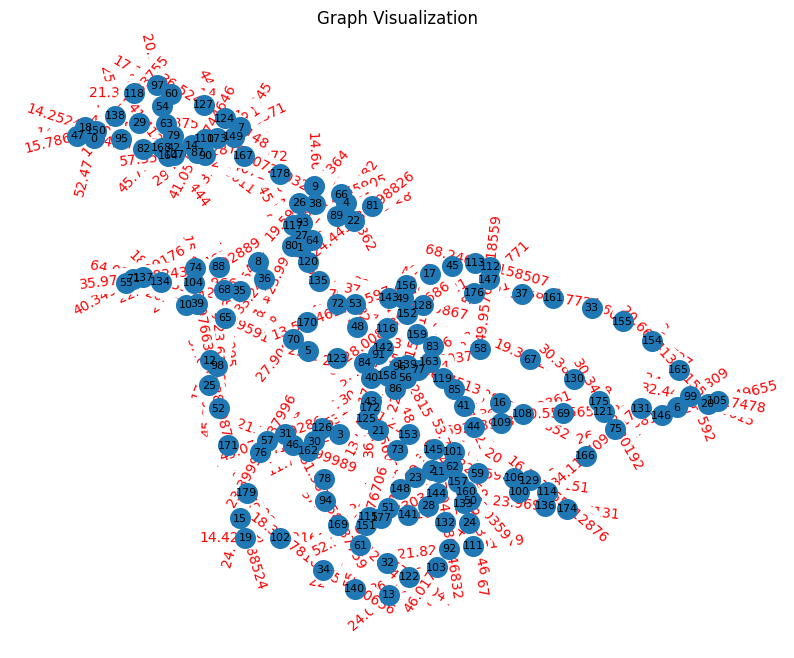

In [10]:
# Visulaize the gragh
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=200)
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_color='red')
nx.draw_networkx_labels(G, pos, font_size=8, font_color='black')
plt.title("Graph Visualization")
plt.axis('off')
plt.show()

In [12]:
edge_weights = [data['weight'] for u, v, data in G.edges(data=True)]

print("--- Edge Weight Distribution ---")
print(f"Number of edges: {len(edge_weights)}")
print(f"Minimum weight: {np.min(edge_weights):.2f}")
print(f"Maximum weight: {np.max(edge_weights):.2f}")
print(f"Mean weight: {np.mean(edge_weights):.2f}")
print(f"Median weight: {np.median(edge_weights):.2f}")
print(f"Standard deviation of weights: {np.std(edge_weights):.2f}")

--- Edge Weight Distribution ---
Number of edges: 226
Minimum weight: 7.83
Maximum weight: 119.90
Mean weight: 33.03
Median weight: 30.09
Standard deviation of weights: 16.29


# Top Weighted Nodes

In [16]:
# Sort nodes by their average edge weight
sorted_avg_weights = sorted(node_avg_edge_weights.items(), key=lambda item: item[1], reverse=True)

print("Top 10 nodes with the highest average edge weights:")
for node, avg_weight in sorted_avg_weights[:10]:
    print(f"Node {node}: Average Edge Weight = {avg_weight:.2f}")

Top 10 nodes with the highest average edge weights:
Node 109: Average Edge Weight = 63.32
Node 87: Average Edge Weight = 62.05
Node 23: Average Edge Weight = 60.87
Node 90: Average Edge Weight = 60.60
Node 112: Average Edge Weight = 59.10
Node 160: Average Edge Weight = 58.55
Node 41: Average Edge Weight = 57.72
Node 14: Average Edge Weight = 57.42
Node 113: Average Edge Weight = 57.38
Node 120: Average Edge Weight = 56.74


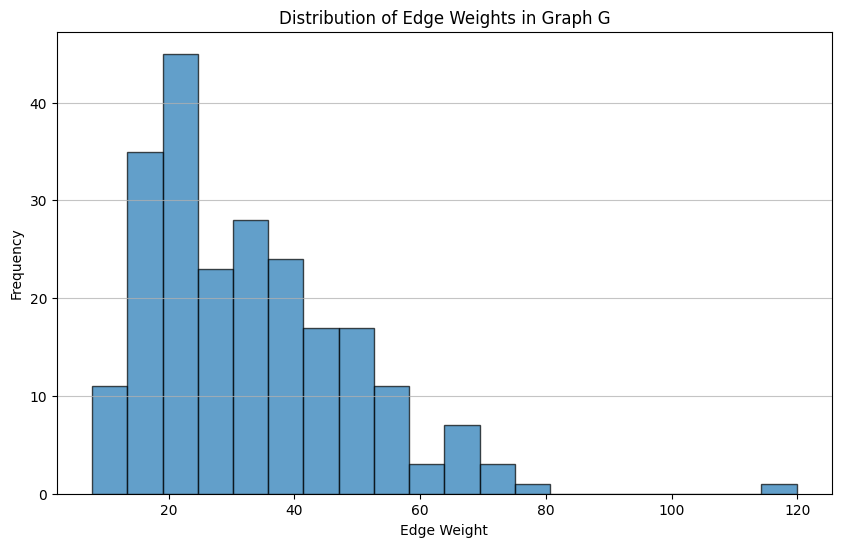

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(edge_weights, bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Edge Weights in Graph G')
plt.xlabel('Edge Weight')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [11]:
node_degrees = dict(G.degree())
sorted_nodes = sorted(node_degrees.items(), key=lambda item: item[1], reverse=True)

print("Top 10 most connected nodes:")
for node, degree in sorted_nodes[:10]:
    print(f"Node {node}: Degree = {degree}")

Top 10 most connected nodes:
Node 95: Degree = 7
Node 65: Degree = 7
Node 139: Degree = 7
Node 38: Degree = 6
Node 8: Degree = 6
Node 134: Degree = 6
Node 3: Degree = 5
Node 90: Degree = 5
Node 128: Degree = 5
Node 158: Degree = 5


In [22]:
# Calculate weighted degree
weighted_degree = {i:0 for i in range(num_nodes)}

for _, row in df.iterrows():
    u = int(row["u"])
    v = int(row["v"])
    w = float(row["w"])

    weighted_degree[u] += w
    weighted_degree[v] += w

sorted_nodes = sorted(weighted_degree.items(), key=lambda x: x[1], reverse=True)

# Find Top K nodes with the highest weighted degrees
K = 25
top_nodes = [node for node,_ in sorted_nodes[:K]]

print(top_nodes)

[90, 87, 143, 134, 128, 139, 108, 3, 157, 85, 149, 65, 51, 28, 2, 44, 177, 95, 106, 133, 109, 56, 23, 176, 38]


In [23]:
top_set = set(top_nodes)

sub_edges = []

for _, row in df.iterrows():
    u = int(row["u"])
    v = int(row["v"])

    if u in top_set and v in top_set:
        sub_edges.append((u, v))

print("Number of nodes in subgraph:", len(top_set))
print("Number of edges in subgraph:", len(sub_edges))

Number of nodes in subgraph: 25
Number of edges in subgraph: 9


In [24]:
K = len(top_set)

max_possible_edges = K * (K - 1) / 2
density = len(sub_edges) / max_possible_edges

print("Subgraph density:", density)

Subgraph density: 0.03


# Breadth First Search (BFS) Algorithm

In [28]:
# Build adjacency list

adj = {i: [] for i in range(num_nodes)}

for _, row in df.iterrows():
    u = int(row["u"])
    v = int(row["v"])

    adj[u].append(v)
    adj[v].append(u)

start_node = sorted_nodes[0][0]
print("Starting node:", start_node)

Starting node: 90


In [26]:
print("Adjacency list (first 5 entries):")
for node, neighbors in list(adj.items())[:5]:
    print(f"Node {node}: {neighbors}")

Adjacency list (first 5 entries):
Node 0: [95, 150]
Node 1: [117, 120]
Node 2: [73, 101, 144]
Node 3: [30, 78, 125, 126, 162]
Node 4: [38, 66, 89]


In [30]:
K = 25

visited = set()
queue = deque()

visited.add(start_node)
queue.append(start_node)

bfs_nodes = [start_node]

while queue and len(bfs_nodes) < K:
    current = queue.popleft()

    for neighbor in adj[current]:
        if neighbor not in visited:
            visited.add(neighbor)
            queue.append(neighbor)
            bfs_nodes.append(neighbor)

            if len(bfs_nodes) >= K:
                break

print("Collected nodes:", bfs_nodes)
print("Number collected:", len(bfs_nodes))

Collected nodes: [90, 14, 42, 87, 107, 167, 79, 95, 110, 164, 173, 82, 149, 178, 54, 168, 0, 18, 47, 138, 7, 63, 124, 38, 97]
Number collected: 25


In [32]:
bfs_set = set(bfs_nodes)

sub_edges = []

for _, row in df.iterrows():
    u = int(row["u"])
    v = int(row["v"])

    if u in bfs_set and v in bfs_set:
        sub_edges.append((u, v))

print("Subgraph edges:", len(sub_edges))

max_possible = K * (K - 1) / 2
density = len(sub_edges) / max_possible

print("Subgraph density:", density)

Subgraph edges: 29
Subgraph density: 0.09666666666666666


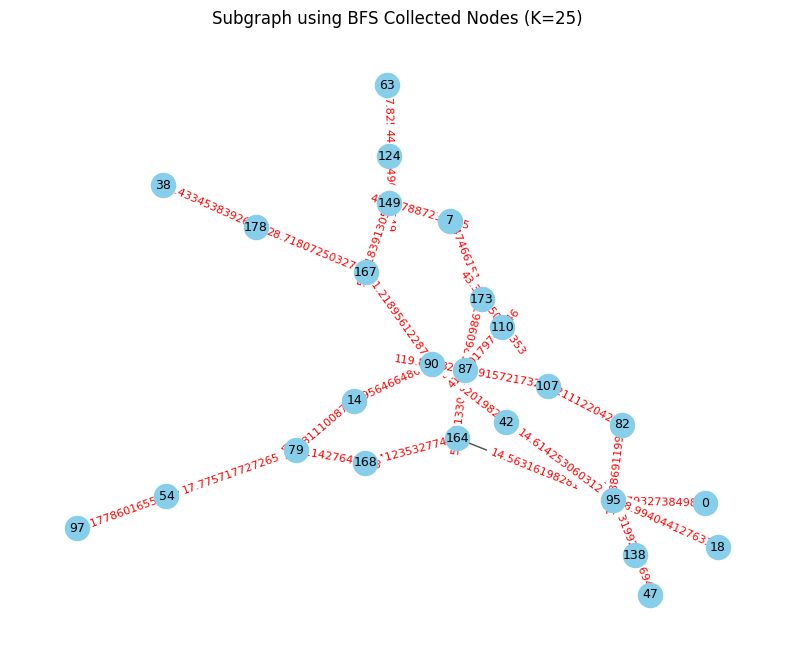

In [33]:
# Create a subgraph using the collected BFS nodes
subgraph_bfs = G.subgraph(bfs_nodes)

plt.figure(figsize=(10, 8))
pos_bfs = nx.spring_layout(subgraph_bfs, seed=42) # For consistent layout

nx.draw_networkx_nodes(subgraph_bfs, pos_bfs, node_size=300, node_color='skyblue')
nx.draw_networkx_edges(subgraph_bfs, pos_bfs, width=1.0, alpha=0.7)

# Only draw edge labels for the subgraph's edges
labels_bfs = nx.get_edge_attributes(subgraph_bfs, 'weight')
nx.draw_networkx_edge_labels(subgraph_bfs, pos_bfs, edge_labels=labels_bfs, font_color='red', font_size=8)

nx.draw_networkx_labels(subgraph_bfs, pos_bfs, font_size=9, font_color='black')
plt.title("Subgraph using BFS Collected Nodes (K=25)")
plt.axis('off')
plt.show()

In [34]:
# Top 3 weighted nodes densities

def bfs_cluster(start_node, K):
    visited = set()
    queue = deque()

    visited.add(start_node)
    queue.append(start_node)

    nodes = [start_node]

    while queue and len(nodes) < K:
        current = queue.popleft()
        for neighbor in adj[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                nodes.append(neighbor)
                if len(nodes) >= K:
                    break
    return nodes

def compute_density(nodes):
    node_set = set(nodes)
    count = 0

    for _, row in df.iterrows():
        u = int(row["u"])
        v = int(row["v"])
        if u in node_set and v in node_set:
            count += 1

    K = len(nodes)
    max_possible = K * (K - 1) / 2
    return count, count / max_possible

K = 25

for i in range(3):
    start = sorted_nodes[i][0]
    nodes = bfs_cluster(start, K)
    edges, density = compute_density(nodes)

    print(f"\nStart node: {start}")
    print("Edges:", edges)
    print("Density:", density)


Start node: 90
Edges: 29
Density: 0.09666666666666666

Start node: 87
Edges: 31
Density: 0.10333333333333333

Start node: 143
Edges: 29
Density: 0.09666666666666666


In [58]:
start_node = 87
sub_nodes = bfs_cluster(start_node, 20)

sub_nodes_sorted = sorted(sub_nodes)

node_to_index = {node: i for i, node in enumerate(sub_nodes_sorted)}

print("Mapping (first 5):")
for k in list(node_to_index.items())[:5]:
    print(k)

print("Collected nodes:", sub_nodes)

Mapping (first 5):
(0, 0)
(7, 1)
(14, 2)
(18, 3)
(42, 4)
Collected nodes: [87, 90, 110, 164, 173, 14, 42, 107, 167, 95, 168, 7, 79, 82, 149, 178, 0, 18, 47, 138]


In [59]:
sub_set = set(sub_nodes_sorted)

sub_edges = []

for _, row in df.iterrows():
    u = int(row["u"])
    v = int(row["v"])
    w = float(row["w"])

    if u in sub_set and v in sub_set:
        sub_edges.append((u, v, w))

print("Number of subgraph edges:", len(sub_edges))

Number of subgraph edges: 24


In [60]:
num_qubits = len(sub_nodes_sorted)

pauli_list = []
coeffs = []

for u, v, w in sub_edges:

    i = node_to_index[u]
    j = node_to_index[v]

    pauli = ['I'] * num_qubits
    pauli[i] = 'Z'
    pauli[j] = 'Z'

    pauli_str = ''.join(pauli)

    pauli_list.append(pauli_str)
    coeffs.append(-0.5 * w)

cost_hamiltonian = SparsePauliOp(pauli_list, coeffs)

print("Number of Hamiltonian terms:", len(cost_hamiltonian))

Number of Hamiltonian terms: 24


# QOAO Implementaion for the subgraph

In [61]:
def create_qaoa_circuit(params):
    """
    Builds a QAOA circuit for p=1.

    params = [gamma, beta]
    gamma controls the cost layer
    beta controls the mixer layer
    """

    gamma = params[0]
    beta = params[1]

    qc = QuantumCircuit(num_qubits)


    for i in range(num_qubits):
        qc.x(i)
        qc.h(i)

    # Apply cost Hamiltonian evolution, Each term corresponds to RZZ rotation
    for u, v, w in sub_edges:

        i = node_to_index[u]
        j = node_to_index[v]

        theta = 2 * gamma * (-0.5 * w)
        qc.rzz(theta, i, j)

    # Step 3: Apply mixer layer
    for i in range(num_qubits):
        qc.rx(2 * beta, i)

    return qc

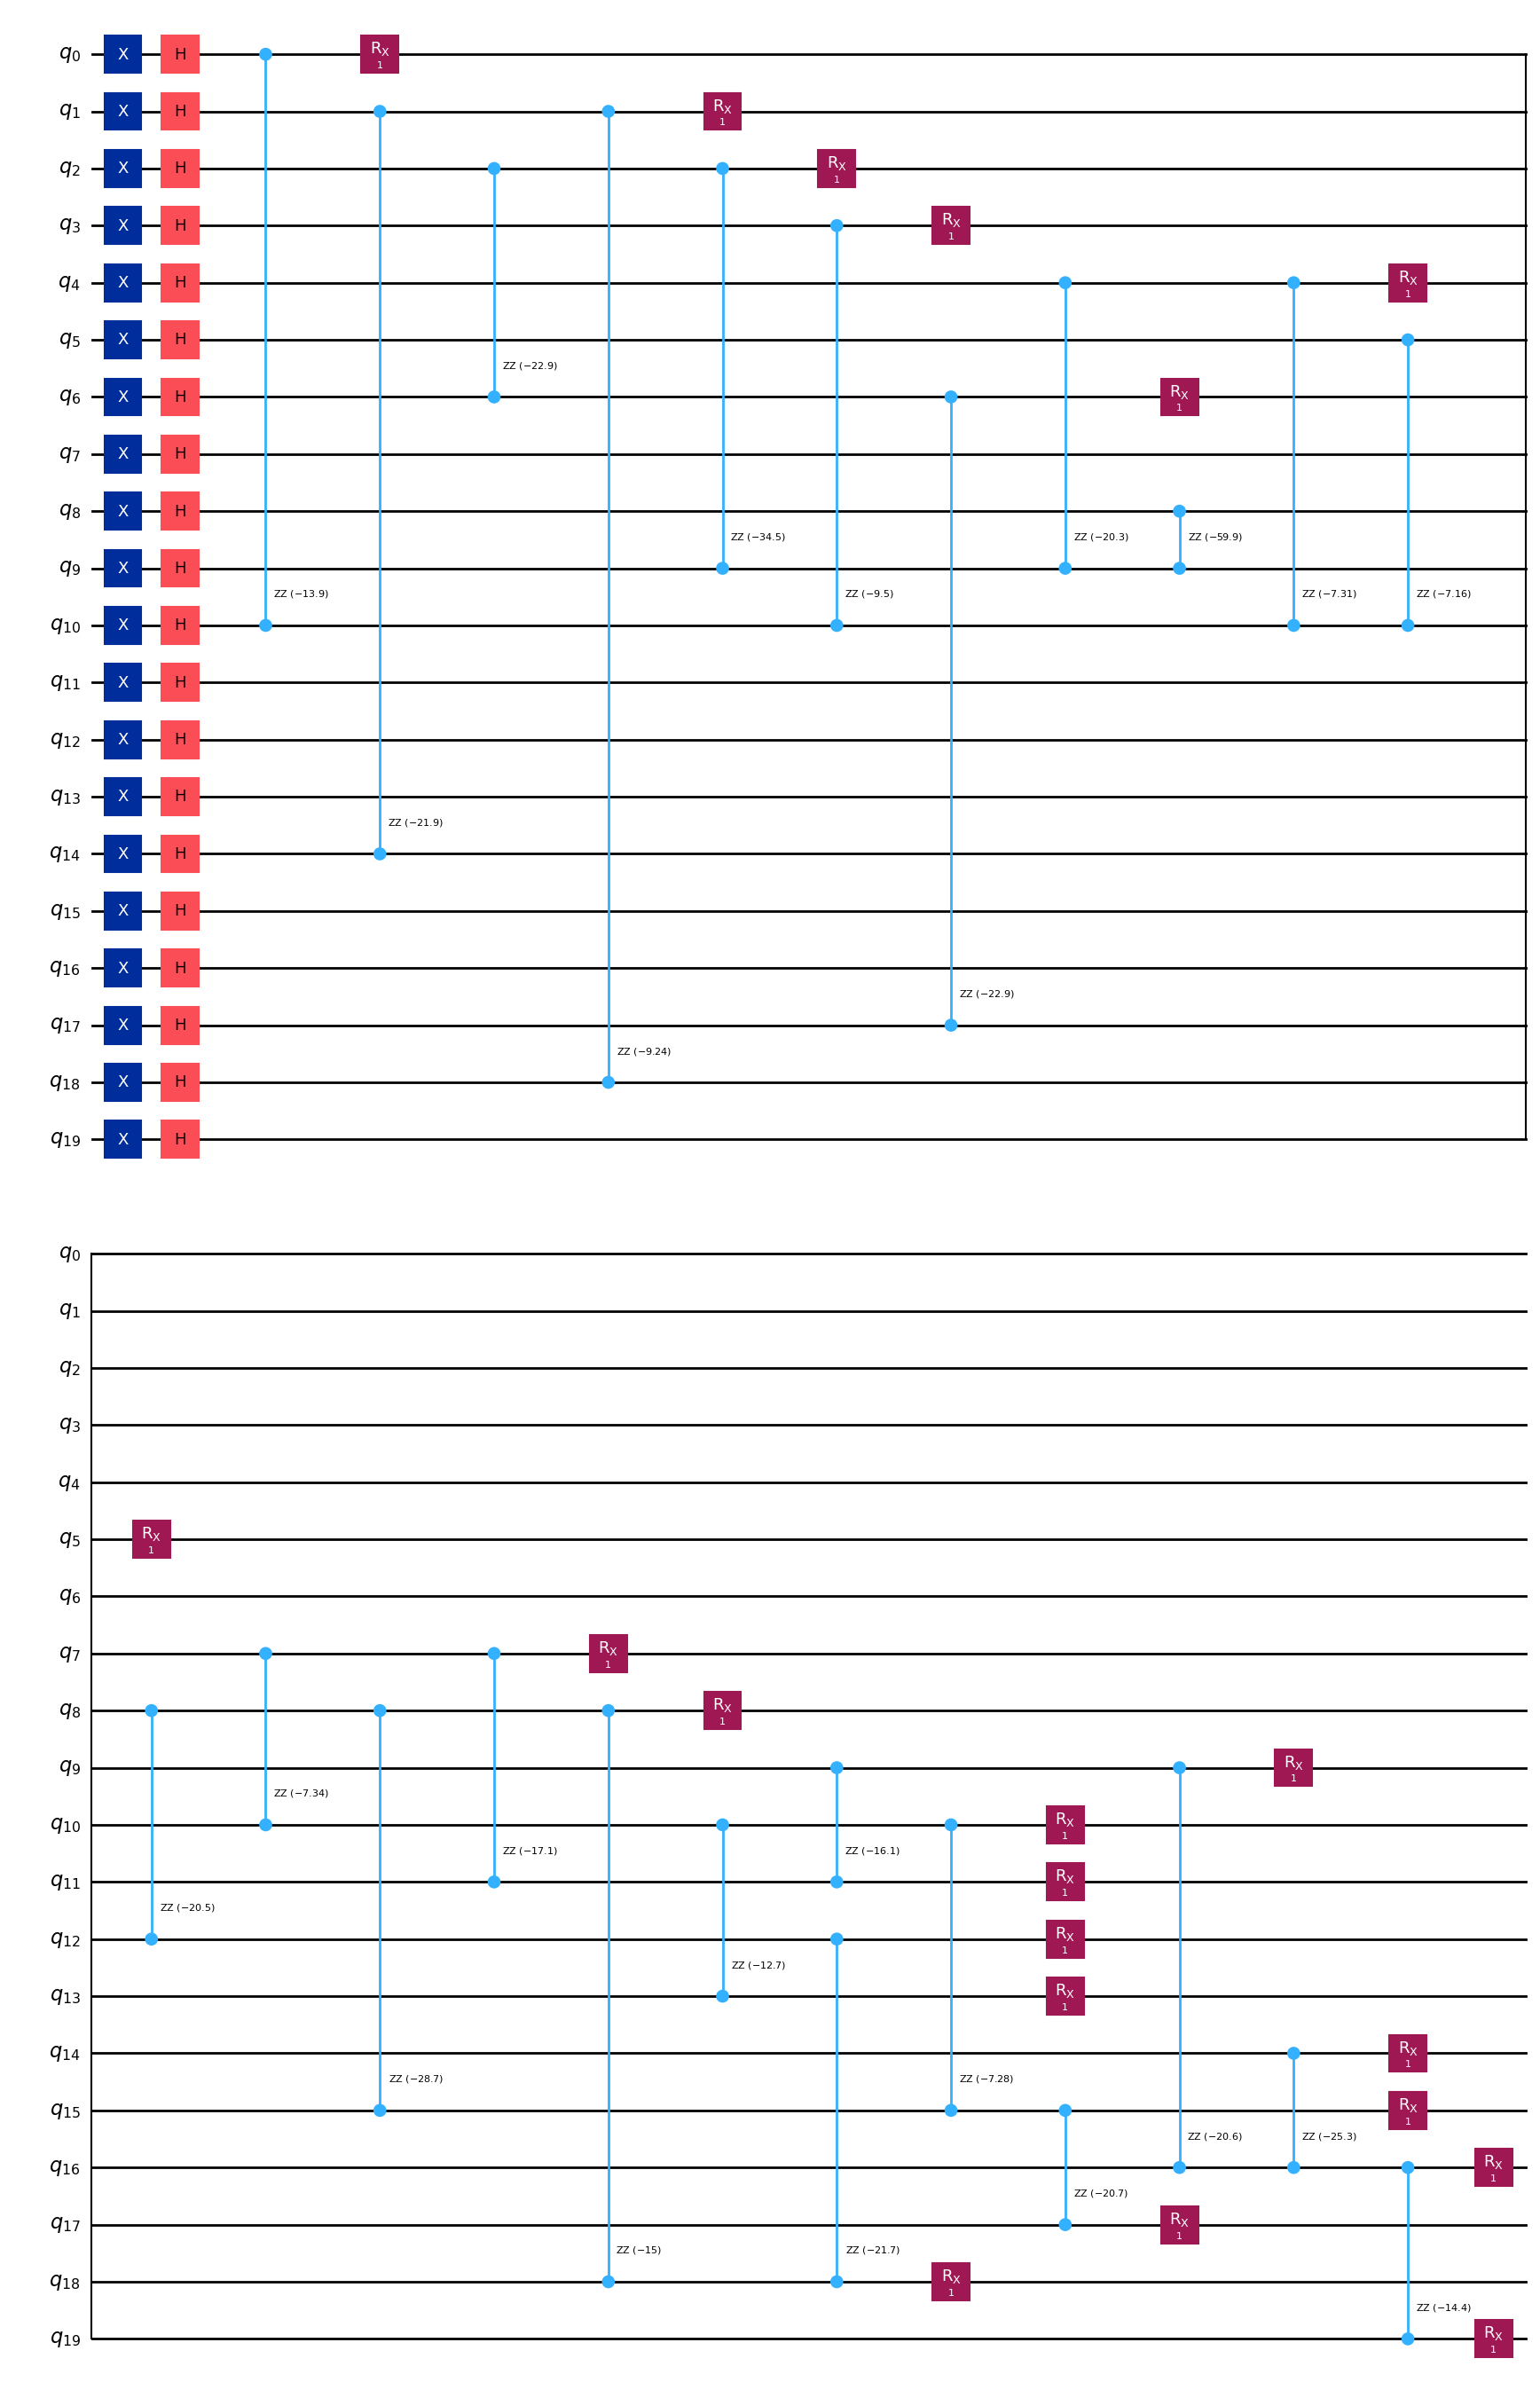

In [62]:
# a sample circuit with dummy parameters for visualization

# Example values for gamma and beta
sample_params = [0.5, 0.5]
sample_circuit = create_qaoa_circuit(sample_params)

sample_circuit.draw(output='mpl')

In [63]:
# Create estimator object (simulator using exact statevector)
estimator = StatevectorEstimator()

def compute_expectation(params):
    """
    Computes expectation value <H> for given QAOA parameters.

    params = [gamma, beta]
    Returns expectation value (energy).
    """

    qc = create_qaoa_circuit(params)

    job = estimator.run([(qc, cost_hamiltonian)])
    result = job.result()

    value = result[0].data.evs

    return value

In [64]:
val = compute_expectation([0.1, 0.2])
print("Energy:", val)

Energy: -13.514418304375369


In [71]:
def objective(params):
    """
    Optimization objective.
    We minimize expectation value.
    """
    return -compute_expectation(params)

best_energy = -1e9
best_params = None

for i in range(10):
    initial_guess = np.random.uniform(0, 2*np.pi, 2)

    result = minimize(
        objective,
        initial_guess,
        method="COBYLA",
        options={'maxiter': 30}
    )

    energy = -result.fun

    print(f"Run {i+1}: Energy = {energy}")

    if energy > best_energy:
        best_energy = energy
        best_params = result.x

print("\nBest energy:", best_energy)
print("Best parameters:", best_params)

Run 1: Energy = 35.70913423039138
Run 2: Energy = 60.89847883433311
Run 3: Energy = 32.82007389785792
Run 4: Energy = 49.97344376655061
Run 5: Energy = 27.812648843496596
Run 6: Energy = 17.51315484923345
Run 7: Energy = 5.926397030496673
Run 8: Energy = 33.28533269648889
Run 9: Energy = 50.219940357769495
Run 10: Energy = 26.576282487850598

Best energy: 60.89847883433311
Best parameters: [3.20712571 5.37330497]


In [76]:
def get_most_probable_bitstring(params):
    """
    Returns the most probable bitstring from the QAOA state.
    """
    qc = create_qaoa_circuit(params)

    state = Statevector.from_instruction(qc)
    probs = state.probabilities()
    max_index = np.argmax(probs)
    bitstring = format(max_index, f'0{num_qubits}b')

    return bitstring, probs[max_index]



In [77]:
bitstring, prob = get_most_probable_bitstring(result.x)

print("Most probable bitstring:", bitstring)
print("Probability:", prob)

Most probable bitstring: 00110100110111001111
Probability: 0.00015015290929433947


# Quantum Preconditioning via correlation matrix

In [84]:
def get_statevector(params):
    qc = create_qaoa_circuit(params)
    state = Statevector.from_instruction(qc)
    return state


In [88]:
def compute_correlations(state, num_qubits):
    """
    Compute <Z_i Z_j> for all pairs in subgraph.
    Returns dictionary {(i,j): value}
    """

    correlations = {}

    for i in range(num_qubits):
        for j in range(i+1, num_qubits):

            # Build ZZ operator
            pauli = ['I'] * num_qubits
            pauli[i] = 'Z'
            pauli[j] = 'Z'

            op = SparsePauliOp(''.join(pauli))

            value = np.real(state.expectation_value(op))

            correlations[(i,j)] = value

    return correlations

In [89]:
state = get_statevector(best_params)

correlations = compute_correlations(state, len(sub_nodes_sorted))

# Print strongest correlations
sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

print("Top 10 strongest correlations:")
for pair, val in sorted_corr[:10]:
    print(pair, "->", round(val,3))

Top 10 strongest correlations:
(14, 16) -> -0.823
(16, 19) -> -0.815
(14, 19) -> 0.806
(15, 17) -> -0.751
(0, 5) -> -0.612
(1, 7) -> 0.427
(6, 16) -> 0.425
(6, 14) -> -0.421
(6, 19) -> -0.416
(1, 4) -> 0.342


In [107]:
# Copy original dataframe
df_preconditioned = df.copy()

# Set amplification factors
boost_factor = 1.8
reduce_factor = 0.75
threshold = 0.7

for (i, j), corr in correlations.items():

    if abs(corr) > threshold:

        # Get real node IDs
        node_i = sub_nodes_sorted[i]
        node_j = sub_nodes_sorted[j]

        # Find matching edge in dataframe
        mask1 = (df_preconditioned["u"] == node_i) & (df_preconditioned["v"] == node_j)
        mask2 = (df_preconditioned["u"] == node_j) & (df_preconditioned["v"] == node_i)

        if corr < 0:
            # Strong anti-correlation → boost weight
            df_preconditioned.loc[mask1 | mask2, "w"] *= boost_factor

        else:
            # Strong positive correlation → reduce weight
            df_preconditioned.loc[mask1 | mask2, "w"] *= reduce_factor

In [108]:
def compute_full_cut_df(dataframe, partition):
    total = 0
    for _, row in dataframe.iterrows():
        u = int(row["u"])
        v = int(row["v"])
        w = float(row["w"])
        if partition[u] != partition[v]:
            total += w
    return total

In [132]:
random_partition = {node: np.random.randint(0,2) for node in range(num_nodes)}
random_refined = local_improvement(df_preconditioned, random_partition.copy())

random_cut_new = compute_full_cut_df(df_preconditioned, random_refined)

print("Random after quantum preconditioning:", random_cut_new)

Random after quantum preconditioning: 6664.616252999138


In [133]:
original_cut = compute_full_cut(df, random_refined)
print("Original graph cut (after quantum preconditioning):", original_cut)

Original graph cut (after quantum preconditioning): 6568.097199330371


In [113]:
np.random.seed(42)
fixed_partition = {node: np.random.randint(0,2) for node in range(num_nodes)}

orig_refined = local_improvement(df, fixed_partition.copy())
orig_cut = compute_full_cut_df(df, orig_refined)
print("Original cut:", orig_cut)

Original cut: 6433.11417389992


In [114]:
pre_refined = local_improvement(df_preconditioned, fixed_partition.copy())
pre_cut_original_eval = compute_full_cut_df(df, pre_refined)

print("Preconditioned cut (evaluated on original graph):", pre_cut_original_eval)

Preconditioned cut (evaluated on original graph): 6433.11417389992


In [134]:
best_cut = -1
best_seed = None
best_partition = None

for seed in range(10):

    np.random.seed(seed)

    # Random initial partition
    fixed_partition = {node: np.random.randint(0,2) for node in range(num_nodes)}

    # Local improvement on preconditioned graph
    refined = local_improvement(df_preconditioned, fixed_partition.copy())

    # Evaluate on original graph
    cut_value = compute_full_cut_df(df, refined)

    print(f"Seed {seed} -> Cut = {cut_value}")

    if cut_value > best_cut:
        best_cut = cut_value
        best_seed = seed
        best_partition = refined

print("\n===== BEST RESULT =====")
print("Best seed:", best_seed)
print("Best cut:", best_cut)

Seed 0 -> Cut = 6360.111483080633
Seed 1 -> Cut = 6309.2746760581795
Seed 2 -> Cut = 6294.581088469323
Seed 3 -> Cut = 6373.125544093183
Seed 4 -> Cut = 6237.293732309964
Seed 5 -> Cut = 6310.493602449648
Seed 6 -> Cut = 6509.593574601307
Seed 7 -> Cut = 6468.180837493796
Seed 8 -> Cut = 6402.92428081753
Seed 9 -> Cut = 6538.1273700210195

===== BEST RESULT =====
Best seed: 9
Best cut: 6538.1273700210195


In [136]:
final_seed = 9
np.random.seed(final_seed)

fixed_partition = {node: np.random.randint(0,2) for node in range(num_nodes)}
final_partition = local_improvement(df_preconditioned, fixed_partition.copy())

final_cut = compute_full_cut_df(df, final_partition)

print("FINAL CUT:", final_cut)

FINAL CUT: 6538.1273700210195


In [137]:
final_bitstring = [final_partition[i] for i in range(num_nodes)]
print(final_bitstring)


[1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0]


In [139]:
total_weight = df["w"].sum()
print("Total weight:", total_weight)

print("Final cut:", final_cut)

mpes_ratio = final_cut / total_weight
print("MPES ratio:", mpes_ratio)

Total weight: 7465.707486325382
Final cut: 6538.1273700210195
MPES ratio: 0.8757545593631453
